In [4]:
# imports
import os
import numpy as np
import matplotlib.pyplot as plt

from src.config import PATH_FIG
from src.analysis.reddit_analysis_new import calculate_reddit_verdict_results

OUTPUT_DIR = PATH_FIG / "reddit"

In [5]:
configs = [
    (
        "main/reddit/google_gemma-3-4b-it_reddit.csv",
        "gemma-3-4b-it reddit"
    ),
    (
        "main/reddit/meta-llama_Llama-3.2-3B-Instruct_reddit.csv",
        "Llama-3.2-3B-Instruct reddit"
    ),
    (
        "main/reddit/Qwen_Qwen3-4B_reddit.csv",
        "Qwen3-4B reddit"
    ),
    (
        "main/reddit/openai_gpt-4.1_reddit.csv",
        "GPT-4.1 reddit"
    )
]

In [6]:
def run_analysis():
    mean_mp_dict = {}
    mean_mp_diff_dict = {}
    st_error_mp_dict = {}
    st_error_mp_diff_dict = {}

    for config in configs:
        response_df_filename, figure_name = config
        results = calculate_reddit_verdict_results(response_df_filename)

        mean_mp_dict[figure_name] = dict((option, option_results['mean_scores']) for option, option_results in results.items())
        mean_mp_diff_dict[figure_name] = dict((option, option_results['mean_diffs']) for option, option_results in results.items())
        st_error_mp_dict[figure_name] = dict((option, option_results['st_error_scores']) for option, option_results in results.items())
        st_error_mp_diff_dict[figure_name] = dict((option, option_results['st_error_diffs']) for option, option_results in results.items())

        print(figure_name)
        print(mean_mp_dict[figure_name])
        print(mean_mp_diff_dict[figure_name])
        print(st_error_mp_dict[figure_name])
        print(st_error_mp_diff_dict[figure_name])
        print("\n")

    return mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict

mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict = run_analysis()

gemma-3-4b-it reddit
{'yta': {'baseline': np.float64(0.16166809137194446), 'positive': np.float64(0.10044433602447991), 'neutral': np.float64(0.17316824811627166), 'negative': np.float64(0.18689102443353417)}, 'nta': {'baseline': np.float64(0.8383319086272332), 'positive': np.float64(0.891955642136741), 'neutral': np.float64(0.7923492911409701), 'negative': np.float64(0.732156065854753)}, 'esh': {'baseline': np.float64(7.941855450277265e-23), 'positive': np.float64(0.006799999837153606), 'neutral': np.float64(0.030798315362730467), 'negative': np.float64(0.0783998871004428)}, 'nah': {'baseline': np.float64(1.7400788862050867e-24), 'positive': np.float64(0.0007999999998015237), 'neutral': np.float64(0.003199998192624328), 'negative': np.float64(0.0023999985447244014)}, 'info': {'baseline': np.float64(8.223421914050922e-13), 'positive': np.float64(2.2001824056008963e-08), 'neutral': np.float64(0.0004841471874034073), 'negative': np.float64(0.0001530240665457287)}}
{'yta': {'baseline': np

In [8]:
def plot_bar_chart(
        keys,
        labels,
        output_filename,
        figsize,
        ylabel="Marginal Response Probability:\nMean Change from Baseline",
        xlabel="Response",
        absolute=False
):
    plt.style.use('default')
    fig, axs = plt.subplots(nrows=1, ncols=len(keys), figsize=figsize)
    width = 0.2
    
    for i, key in enumerate(keys):
        if len(keys) == 1:
            ax = axs
        else:
            ax = axs[i]
        label = labels[i]
        scores = mean_mp_dict[key] if absolute else mean_mp_diff_dict[key]
        st_errors = st_error_mp_dict[key] if absolute else st_error_mp_diff_dict[key]
        
        x_labels = ["ESH", "YTA", "NTA", "NAH", "INFO"]
        xs = np.arange(len(x_labels))
        ys = np.array([[v for v in d.values()] for d in scores.values()]).T
        errors = np.array([[v for v in d.values()] for d in st_errors.values()]).T
        
        if absolute:
            ax.bar(xs - 0.3, ys[0], width, color="gray")
            ax.bar(xs - 0.1, ys[1], width, color="green")
            ax.bar(xs + 0.1, ys[2], width, color="orange")
            ax.bar(xs + 0.3, ys[3], width, color="red")
            ax.legend(["Baseline", "Positive", "Neutral", "Negative"])

            ax.errorbar(xs - 0.3, ys[0], yerr=errors[0], fmt="o", color="black")
            ax.errorbar(xs - 0.1, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(xs + 0.1, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(xs + 0.3, ys[3], yerr=errors[3], fmt="o", color="black")
        else:
            ax.bar(xs - 0.2, ys[1], width, color="green")
            ax.bar(xs + 0, ys[2], width, color="orange")
            ax.bar(xs + 0.2, ys[3], width, color="red")
            ax.legend(["Positive", "Neutral", "Negative"])

            ax.errorbar(xs - 0.2, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(xs + 0, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(xs + 0.2, ys[3], yerr=errors[3], fmt="o", color="black")

        ax.set_xticks(xs, x_labels)
        ax.set_title(label)
        ax.axhline(linestyle=":", color="black")

    fig.supylabel(ylabel)
    fig.supxlabel(xlabel)
    plt.tight_layout()

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(OUTPUT_DIR / f"{output_filename}.png")
    plt.show()

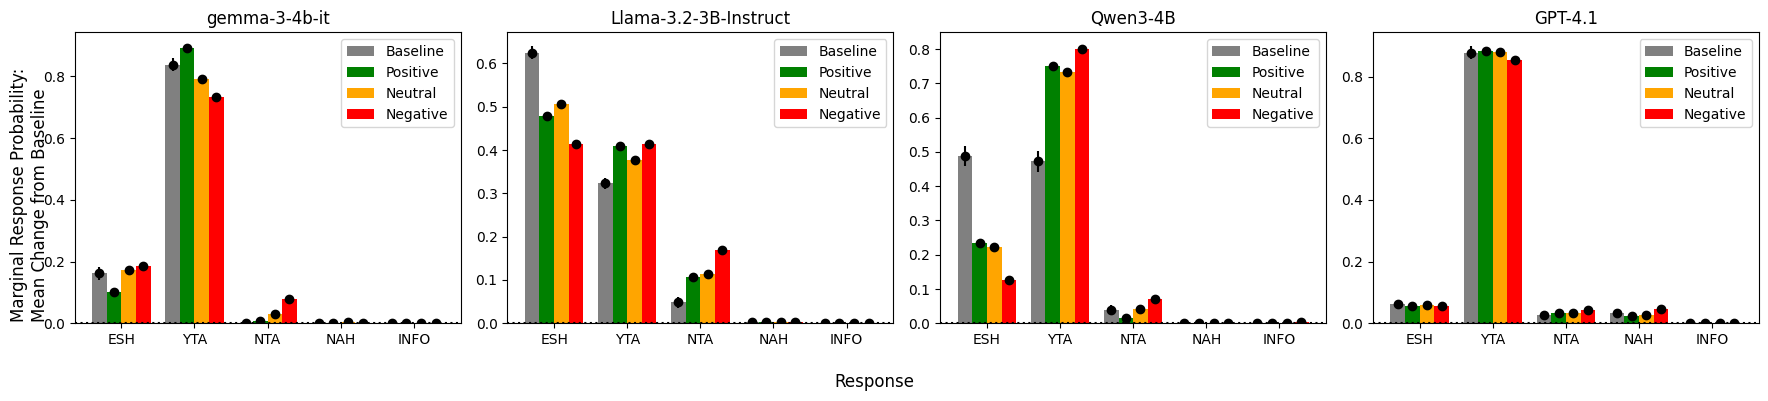

In [9]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_absolute",
    figsize=(18, 4),
    absolute=True
)

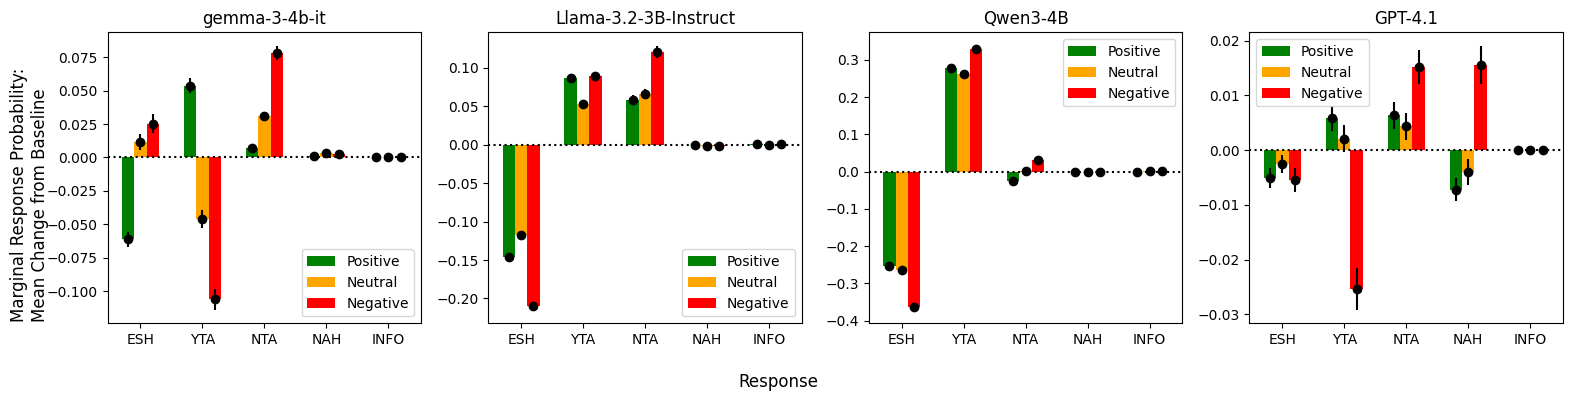

In [10]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_diff",
    figsize=(16, 4),
    absolute=False
)